# Machine Learning Fundamentals with scikit-learn

### Classification, Regression, Clustering, and Outlier Detection

This notebook is a curated walkthrough of core machine-learning concepts using **scikit-learn** and standard demonstration datasets. It covers model-evaluation metrics, supervised-learning algorithms, regularization, tree-based methods, clustering, and anomaly detection.

### Topics Covered

- Classification and regression evaluation metrics
- K-Nearest Neighbors (KNN)
- Logistic Regression and multiclass ROC analysis
- Support Vector Machines (SVM)
- Linear Regression, Ridge, and Lasso
- Decision Trees
- Gradient Boosting
- K-Means Clustering
- Local Outlier Factor (LOF)

**Portfolio note:** This notebook originated as an academic replication exercise. The original code and stored outputs are preserved here, while the surrounding documentation has been reorganized and corrected for clarity. The examples use built-in or synthetically generated datasets rather than a single real-world business dataset.

## 1. Model Evaluation Metrics

Before comparing algorithms, it is useful to establish the metrics used to evaluate classification and regression models.

### 1.1 Binary Classification

**Accuracy**

\[
\text{Accuracy} =
\frac{\text{TP}+\text{TN}}
{\text{TP}+\text{TN}+\text{FP}+\text{FN}}
\]

**Precision**

\[
\text{Precision} =
\frac{\text{TP}}
{\text{TP}+\text{FP}}
\]

**Recall / Sensitivity**

\[
\text{Recall} =
\frac{\text{TP}}
{\text{TP}+\text{FN}}
\]

**F1 Score**

\[
F_1 =
2\frac{\text{Precision}\cdot\text{Recall}}
{\text{Precision}+\text{Recall}}
\]

**Specificity**

\[
\text{Specificity} =
\frac{\text{TN}}
{\text{TN}+\text{FP}}
\]

**AUC-ROC** evaluates the trade-off between true-positive rate and false-positive rate across classification thresholds. Higher area-under-the-curve values generally indicate stronger class discrimination.

**AUC-PR** summarizes the precision-recall trade-off and is particularly useful when the positive class is relatively rare.

**Log Loss**

\[
\text{Log Loss} =
-\frac{1}{n}\sum_{i=1}^{n}
\left[
y_i\log(p_i)+(1-y_i)\log(1-p_i)
\right]
\]

### 1.2 Multiclass Classification

Common multiclass metrics include:

- **Accuracy** — fraction of predictions assigned to the correct class.
- **Macro averaging** — computes a metric independently for each class, then takes an unweighted mean.
- **Weighted averaging** — averages class-level metrics while weighting by class support.
- **Micro averaging** — aggregates all class-level contributions before computing the metric.
- **Confusion matrix** — summarizes the relationship between true and predicted classes.
- **Top-\(k\) accuracy** — counts a prediction as correct when the true class appears among the model's \(k\) highest-ranked predictions.
- **Cohen's Kappa** — measures agreement while accounting for agreement expected by chance:

\[
\kappa = \frac{p_o-p_e}{1-p_e}
\]

### 1.3 Regression Metrics

**Mean Absolute Error**

\[
\text{MAE} =
\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
\]

**Mean Squared Error**

\[
\text{MSE} =
\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
\]

**Root Mean Squared Error**

\[
\text{RMSE} =
\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
\]

**Mean Absolute Percentage Error**

\[
\text{MAPE} =
\frac{1}{n}\sum_{i=1}^{n}
\left|\frac{y_i-\hat{y}_i}{y_i}\right|\times100
\]

**Coefficient of Determination**

\[
R^2 =
1-\frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
{\sum_{i=1}^{n}(y_i-\bar{y})^2}
\]

**Adjusted \(R^2\)**

\[
R^2_{\text{adj}} =
1-(1-R^2)\frac{n-1}{n-p-1}
\]

Adjusted \(R^2\) accounts for the number of predictors and therefore penalizes unnecessary model complexity.

# 2. Supervised Learning

## 2.1 K-Nearest Neighbors Classification

KNN is a **similarity-based** method. To classify a new observation, the algorithm:

1. computes its distance to the training observations;
2. identifies the \(k\) nearest neighbors;
3. obtains the class labels of those neighbors; and
4. assigns the class receiving the largest vote, optionally weighting nearer observations more heavily.

The following example uses two Iris features, standardizes them in a pipeline, and compares uniform and distance-weighted decision boundaries.

In [1]:
# Imports
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
iris = load_iris(as_frame=True)
X = iris.data[["sepal length (cm)", "sepal width (cm)"]]
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

In [2]:
clf = Pipeline(
steps=[("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=11))]
)

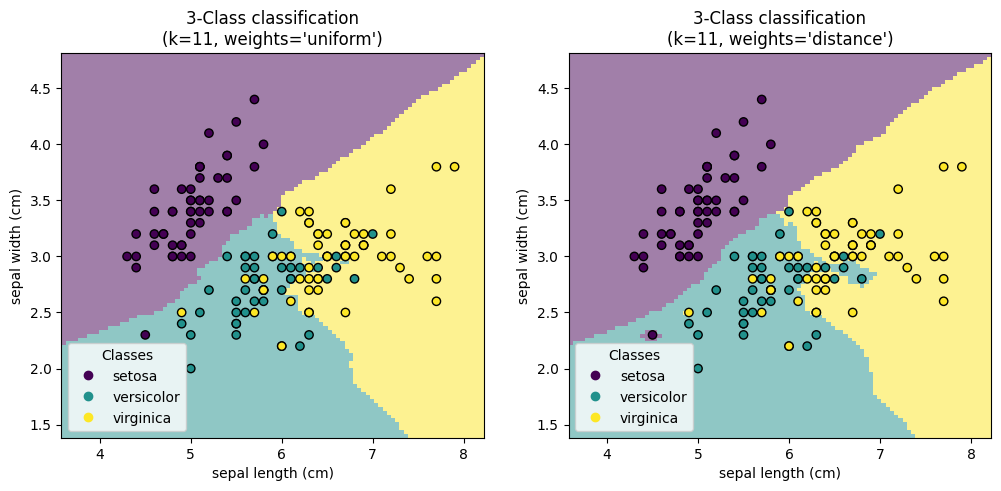

In [3]:
_, axs = plt.subplots(ncols=2, figsize=(12, 5))
for ax, weights in zip(axs, ("uniform", "distance")):
    clf.set_params(knn__weights=weights).fit(X_train, y_train)
    disp = DecisionBoundaryDisplay.from_estimator(
    clf,
    X_test,
    response_method="predict",
    plot_method="pcolormesh",
    xlabel=iris.feature_names[0],
    ylabel=iris.feature_names[1],
    shading="auto",
    alpha=0.5,
    ax=ax,
    )
    scatter = disp.ax_.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolors="k")
    disp.ax_.legend(
    scatter.legend_elements()[0],
    iris.target_names,
    loc="lower left",
    title="Classes",
    )
    _ = disp.ax_.set_title(
    f"3-Class classification\n(k={clf[-1].n_neighbors}, weights={weights!r})"
    )
plt.show()

In [4]:
y_pred = clf.predict(X_test)
accuracy_score(y_pred, y_test)

0.631578947368421

In [5]:
confusion_matrix(y_test, y_pred)

array([[13,  0,  0],
       [ 0,  7,  6],
       [ 0,  8,  4]])

### KNN Classification Result

For the final fitted configuration stored in this run:

- **Test accuracy:** 0.632
- The confusion matrix shows perfect separation of the first Iris class, while most errors occur between the second and third classes.

Because only two Iris features are used, this example is primarily useful for visualizing how KNN forms decision regions rather than maximizing predictive performance.

## 2.2 K-Nearest Neighbors Regression

KNN can also estimate a continuous target. Instead of voting for a class, the regressor combines the target values of nearby training observations.

The example below compares:

- **uniform weighting**, where each neighbor contributes equally; and
- **distance weighting**, where nearer observations exert greater influence.

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import neighbors
rng = np.random.RandomState(0)
X_train = np.sort(5 * rng.rand(40, 1), axis=0)
X_test = np.linspace(0, 5, 500)[:, np.newaxis]
y = np.sin(X_train).ravel() #Y_train
# Add noise to targets
y[::5] += 1 * (0.5 - np.random.rand(8))

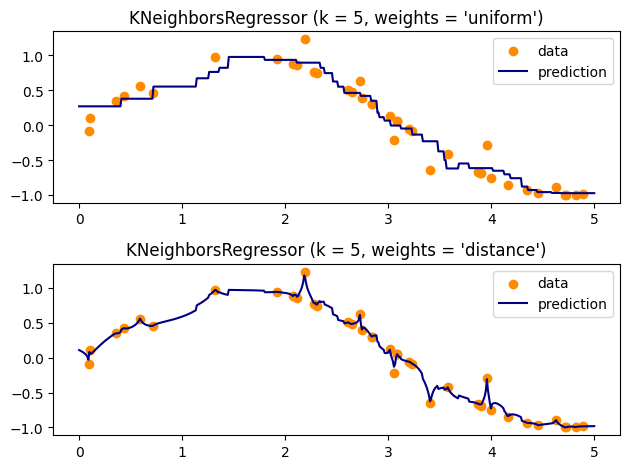

In [7]:
n_neighbors = 5
for i, weights in enumerate(["uniform", "distance"]):
    knn = neighbors.KNeighborsRegressor(n_neighbors, weights=weights)
    y_ = knn.fit(X_train, y).predict(X_test) #Y_pred
    plt.subplot(2, 1, i + 1)
    plt.scatter(X_train, y, color="darkorange", label="data")
    plt.plot(X_test, y_, color="navy", label="prediction")
    plt.axis("tight")
    plt.legend()
    plt.title("KNeighborsRegressor (k = %i, weights = '%s')" % (n_neighbors, weights))

plt.tight_layout()
plt.show()

## 2.3 Logistic Regression and Multiclass ROC Analysis

Logistic regression models class probabilities by transforming a linear combination of predictors through a logistic function. For multiclass problems, the model can estimate one probability per class and evaluate discrimination using one-vs-rest ROC curves.

For a binary response, the sigmoid is:

\[
\sigma(z)=\frac{1}{1+e^{-z}}
\]

and the corresponding log-loss objective is:

\[
J(\theta) =
-\frac{1}{n}\sum_{i=1}^{n}
\left[
y_i\log(\hat y_i)+(1-y_i)\log(1-\hat y_i)
\right]
\]

The example augments the Iris features with random noise variables to create a more challenging classification setting before evaluating multiclass ROC performance.

In [8]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
target_names = iris.target_names
X, y = iris.data, iris.target
y = iris.target_names[y]
random_state = np.random.RandomState(0)
n_samples, n_features = X.shape
n_classes = len(np.unique(y))
X = np.concatenate([X, random_state.randn(n_samples, 200 * n_features)], axis=1)
(
    X_train,
    X_test,
    y_train,
    y_test,
) = train_test_split(X, y, test_size=0.5, stratify=y, random_state=0)

In [9]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression()
y_score = classifier.fit(X_train, y_train).predict_proba(X_test)

In [10]:
from sklearn.preprocessing import LabelBinarizer
label_binarizer = LabelBinarizer().fit(y_train)
y_onehot_test = label_binarizer.transform(y_test)
y_onehot_test.shape # (n_samples, n_classes)

(75, 3)

Micro-averaged One-vs-Rest ROC AUC score:
0.77
Macro-averaged One-vs-Rest ROC AUC score:
0.78


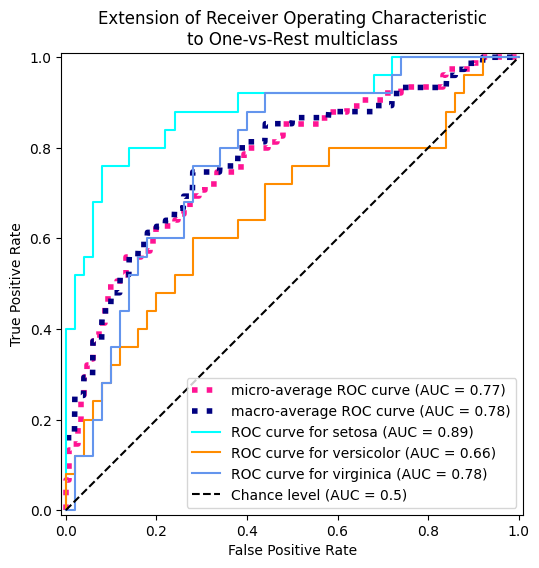

In [11]:
from itertools import cycle
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve
from sklearn.metrics import RocCurveDisplay

# store the fpr, tpr, and roc_auc for all averaging strategies
fpr, tpr, roc_auc = dict(), dict(), dict()
# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_onehot_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

print(f"Micro-averaged One-vs-Rest ROC AUC score:\n{roc_auc['micro']:.2f}")

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_onehot_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    
fpr_grid = np.linspace(0.0, 1.0, 1000)

# Interpolate all ROC curves at these points
mean_tpr = np.zeros_like(fpr_grid)

for i in range(n_classes):
    mean_tpr += np.interp(fpr_grid, fpr[i], tpr[i]) # linear interpolation
# Average it and compute AUC
mean_tpr /= n_classes
fpr["macro"] = fpr_grid
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

print(f"Macro-averaged One-vs-Rest ROC AUC score:\n{roc_auc['macro']:.2f}")

fig, ax = plt.subplots(figsize=(6, 6))

plt.plot(
    fpr["micro"],
    tpr["micro"],
    label=f"micro-average ROC curve (AUC = {roc_auc['micro']:.2f})",
    color="deeppink",
    linestyle=":",
    linewidth=4,
)

plt.plot(
    fpr["macro"],
    tpr["macro"],
    label=f"macro-average ROC curve (AUC = {roc_auc['macro']:.2f})",
    color="navy",
    linestyle=":",
    linewidth=4,
)

colors = cycle(["aqua", "darkorange", "cornflowerblue"])
for class_id, color in zip(range(n_classes), colors):
    RocCurveDisplay.from_predictions(
        y_onehot_test[:, class_id],
        y_score[:, class_id],
        name=f"ROC curve for {target_names[class_id]}",
        color=color,
        ax=ax,
        plot_chance_level=(class_id == 2),
    )
    
_ = ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Extension of Receiver Operating Characteristic\nto One-vs-Rest multiclass",
)

### Logistic Regression Result

The stored run reports:

- **Micro-averaged one-vs-rest ROC AUC:** 0.77
- **Macro-averaged one-vs-rest ROC AUC:** 0.78

The plotted class-specific ROC curves make it possible to inspect whether discrimination differs across Iris classes.

## 2.4 Support Vector Machines

Support Vector Machines seek decision boundaries with strong class separation. Different kernels allow the model to represent both linear and nonlinear boundaries.

The following comparison visualizes:

- linear SVC;
- LinearSVC;
- radial-basis-function (RBF) SVC; and
- polynomial SVC.

Using the same two Iris features makes the effect of kernel choice directly visible.

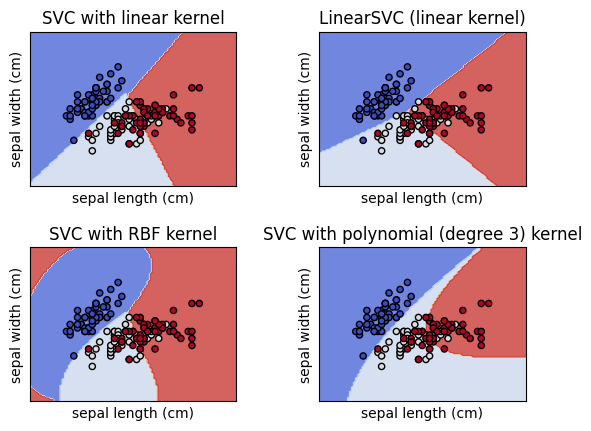

In [12]:
import matplotlib.pyplot as plt
from sklearn import datasets, svm
from sklearn.inspection import DecisionBoundaryDisplay

# import some data to play with
iris = datasets.load_iris()

# Take the first two features. We could avoid this by using a two-dim dataset
X = iris.data[:, :2]
y = iris.target

# we create an instance of SVM and fit out data. We do not scale our
# data since we want to plot the support vectors
C = 1.0 # SVM regularization parameter
models = (
    svm.SVC(kernel="linear", C=C),
    svm.LinearSVC(C=C, max_iter=10000),
    svm.SVC(kernel="rbf", gamma=0.7, C=C),
    svm.SVC(kernel="poly", degree=3, gamma="auto", C=C),
)
models = (clf.fit(X, y) for clf in models)

# title for the plots
titles = (
    "SVC with linear kernel",
    "LinearSVC (linear kernel)",
    "SVC with RBF kernel",
    "SVC with polynomial (degree 3) kernel",
)

# Set-up 2x2 grid for plotting.
fig, sub = plt.subplots(2, 2)
plt.subplots_adjust(wspace=0.4, hspace=0.4)

X0, X1 = X[:, 0], X[:, 1]

for clf, title, ax in zip(models, titles, sub.flatten()):
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        response_method="predict",
        cmap=plt.cm.coolwarm,
        alpha=0.8,
        ax=ax,
        xlabel=iris.feature_names[0],
        ylabel=iris.feature_names[1],
    )
    ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)

plt.show()

## 2.5 Linear Regression

Ordinary Least Squares estimates coefficients that minimize squared residual error.

In matrix form, the closed-form estimator is:

\[
\theta=(X^TX)^{-1}X^Ty
\]

and predictions are computed as:

\[
\hat y=X\theta
\]

The following example uses one feature from scikit-learn's Diabetes dataset so the fitted relationship can be interpreted and plotted easily.

In [13]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

X, y = load_diabetes(return_X_y=True)
X = X[:, [2]] # Use only one feature
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)

In [14]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression().fit(X_train, y_train)

In [15]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = regressor.predict(X_test)

print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

Mean squared error: 2548.07
Coefficient of determination: 0.47


### Baseline Linear Regression Result

- **MSE:** 2548.07
- **\(R^2\):** 0.47

The single-feature model explains roughly 47% of the variance in the held-out target values in this particular split.

## 2.6 Regularized Linear Models

Regularization penalizes model coefficients to control complexity.

### Ridge Regression — L2 Regularization

Ridge adds a squared-coefficient penalty:

\[
\text{Loss}_{\text{Ridge}}
=
\text{RSS}+\lambda\sum_j\beta_j^2
\]

The original notebook labeled this section as L1 regularization, but the code uses `Ridge`, which is an **L2** method.

In [16]:
from sklearn import linear_model
reg = linear_model.Ridge(alpha=.5)

regressor = reg.fit(X_train, y_train)

In [17]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = regressor.predict(X_test)

print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

Mean squared error: 3144.86
Coefficient of determination: 0.35


### Lasso Regression — L1 Regularization

Lasso adds an absolute-value coefficient penalty:

\[
\text{Loss}_{\text{Lasso}}
=
\text{RSS}+\lambda\sum_j|\beta_j|
\]

The original notebook labeled this section as L2 regularization, but the code uses `Lasso`, which is an **L1** method.

In [18]:
from sklearn import linear_model
reg = linear_model.Lasso(alpha=.1)

regressor = reg.fit(X_train, y_train)

In [19]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = regressor.predict(X_test)

print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

Mean squared error: 2602.57
Coefficient of determination: 0.46


### Regression Comparison

| Model | MSE | \(R^2\) |
|---|---:|---:|
| Ordinary Least Squares | 2548.07 | 0.47 |
| Ridge (L2) | 3144.86 | 0.35 |
| Lasso (L1) | 2602.57 | 0.46 |

For this one-feature example and the stored hyperparameters, ordinary least squares achieves the lowest test MSE.

**Plot note:** At the next cell, the variable `regressor` contains the most recently fitted model—Lasso—so the displayed train/test prediction line corresponds to the Lasso fit even though the plot's original title says "Linear Regression."

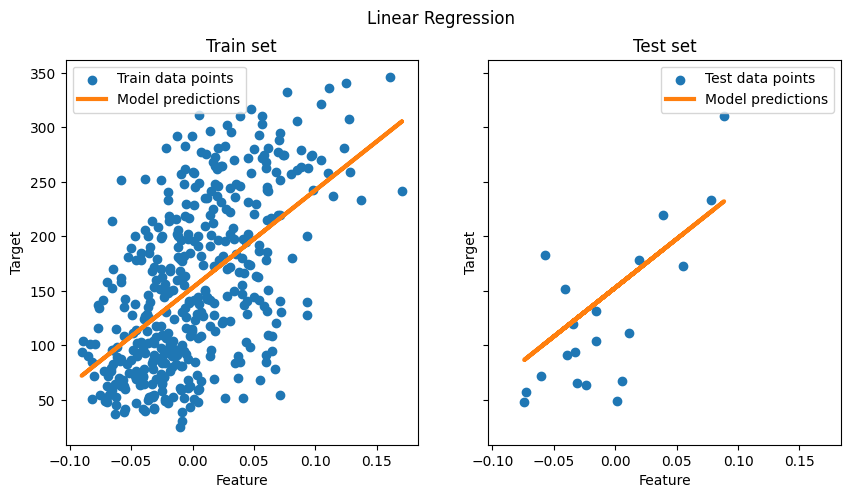

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].scatter(X_train, y_train, label="Train data points")
ax[0].plot(
    X_train,
    regressor.predict(X_train),
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
ax[0].legend()

ax[1].scatter(X_test, y_test, label="Test data points")
ax[1].plot(X_test, y_pred, linewidth=3, color="tab:orange", label="Model predictions")

ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
ax[1].legend()

fig.suptitle("Linear Regression")

plt.show()

## 2.7 Decision Trees

Decision trees recursively split the feature space into regions that improve class purity. Their structure is relatively interpretable because each prediction can be traced through a sequence of feature-based rules.

The example below fits an unconstrained decision-tree classifier on the full Iris dataset and visualizes the resulting tree in both Matplotlib and Graphviz formats.

In [21]:
from sklearn.datasets import load_iris
from sklearn import tree
iris = load_iris()
X, y = iris.data, iris.target
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X, y)

[Text(0.5, 0.9166666666666666, 'x[3] <= 0.8\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.4230769230769231, 0.75, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.46153846153846156, 0.8333333333333333, 'True  '),
 Text(0.5769230769230769, 0.75, 'x[3] <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.5384615384615384, 0.8333333333333333, '  False'),
 Text(0.3076923076923077, 0.5833333333333334, 'x[2] <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.15384615384615385, 0.4166666666666667, 'x[3] <= 1.65\ngini = 0.041\nsamples = 48\nvalue = [0, 47, 1]'),
 Text(0.07692307692307693, 0.25, 'gini = 0.0\nsamples = 47\nvalue = [0, 47, 0]'),
 Text(0.23076923076923078, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.46153846153846156, 0.4166666666666667, 'x[3] <= 1.55\ngini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.38461538461538464, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.5384615384615384, 0.25, '

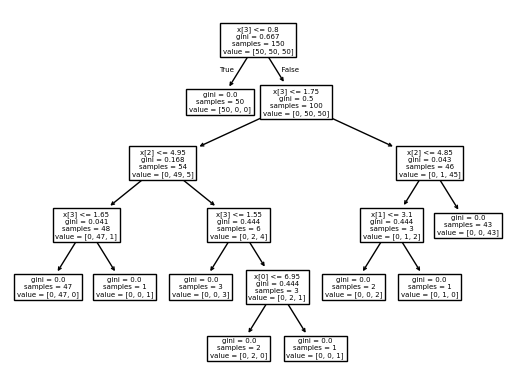

In [22]:
tree.plot_tree(clf)

In [23]:
import graphviz
dot_data = tree.export_graphviz(clf, out_file=None)
graph = graphviz.Source(dot_data)
graph.render("iris")

'iris.pdf'

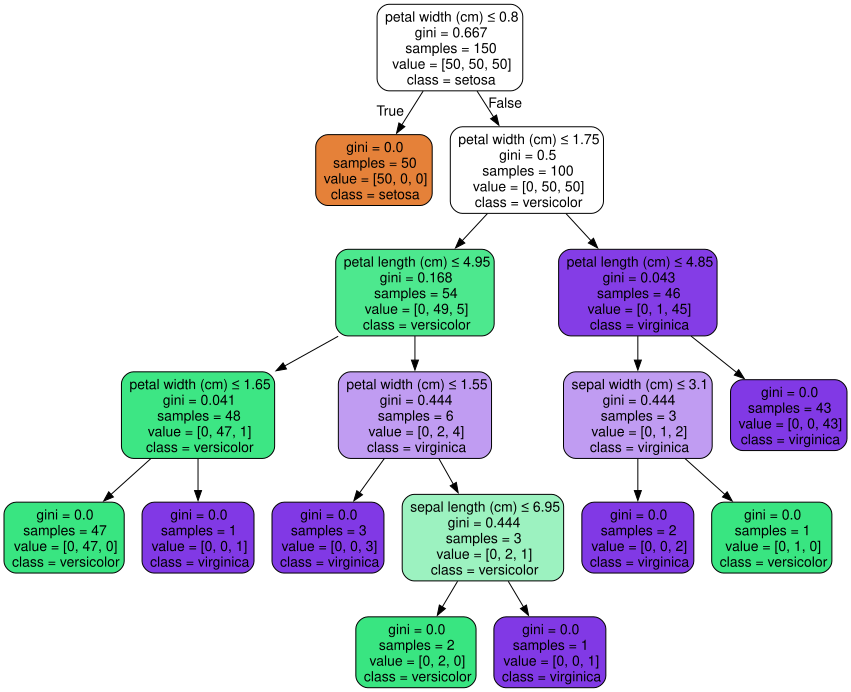

In [24]:
dot_data = tree.export_graphviz(clf, out_file=None,
                    feature_names=iris.feature_names,
                    class_names=iris.target_names,
                    filled=True, rounded=True,
                    special_characters=True)
graph = graphviz.Source(dot_data)
graph

## 2.8 Gradient Boosting

Gradient Boosting builds an ensemble sequentially: each new weak learner is trained to improve on errors left by the preceding ensemble.

The example below fits a `GradientBoostingRegressor` to the Diabetes dataset and tracks training and test deviance across boosting iterations.

In [25]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets, ensemble
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.utils.fixes import parse_version

In [26]:
diabetes = datasets.load_diabetes()
X, y = diabetes.data, diabetes.target

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=13
)
params = {
    "n_estimators": 500,
    "max_depth": 4,
    "min_samples_split": 5,
    "learning_rate": 0.01,
    "loss": "squared_error",
}

In [28]:
reg = ensemble.GradientBoostingRegressor(**params)
reg.fit(X_train, y_train)

mse = mean_squared_error(y_test, reg.predict(X_test))
print("The mean squared error (MSE) on test set: {:.4f}".format(mse))

The mean squared error (MSE) on test set: 3027.4507


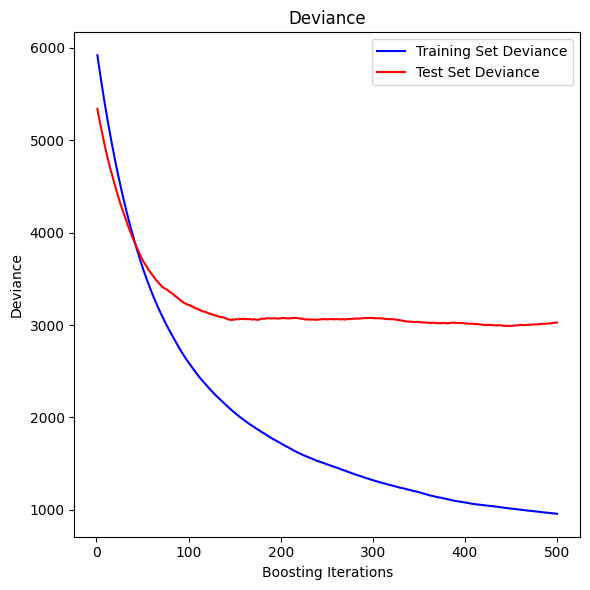

In [29]:
test_score = np.zeros((params["n_estimators"],), dtype=np.float64)
for i, y_pred in enumerate(reg.staged_predict(X_test)):
    test_score[i] = mean_squared_error(y_test, y_pred)
    
fig = plt.figure(figsize=(6, 6))
plt.subplot(1, 1, 1)
plt.title("Deviance")
plt.plot(
    np.arange(params["n_estimators"]) + 1,
    reg.train_score_,
    "b-",
    label="Training Set Deviance",
)
plt.plot(
np.arange(params["n_estimators"]) + 1, test_score, "r-", label="Test Set Deviance"
)
plt.legend(loc="upper right")
plt.xlabel("Boosting Iterations")
plt.ylabel("Deviance")
fig.tight_layout()
plt.show()

### Gradient Boosting Result

The stored run reports a **test MSE of 3027.45**.

The deviance plot is especially useful for diagnosing whether additional boosting iterations continue to improve generalization or begin to overfit the training data.

# 3. Unsupervised Learning

## 3.1 K-Means Clustering

K-Means partitions observations into \(k\) clusters by iteratively alternating between two steps:

1. assign each observation to its nearest centroid;
2. recompute each centroid as the mean of the observations assigned to it.

\[
\text{Cluster}(x_i)=
\arg\min_j \|x_i-c_j\|^2
\]

The examples below deliberately include conditions in which K-Means can behave poorly: a non-optimal number of clusters, anisotropic distributions, unequal variance, and uneven cluster sizes. This highlights the assumptions implicit in centroid-based clustering rather than presenting K-Means as universally appropriate.

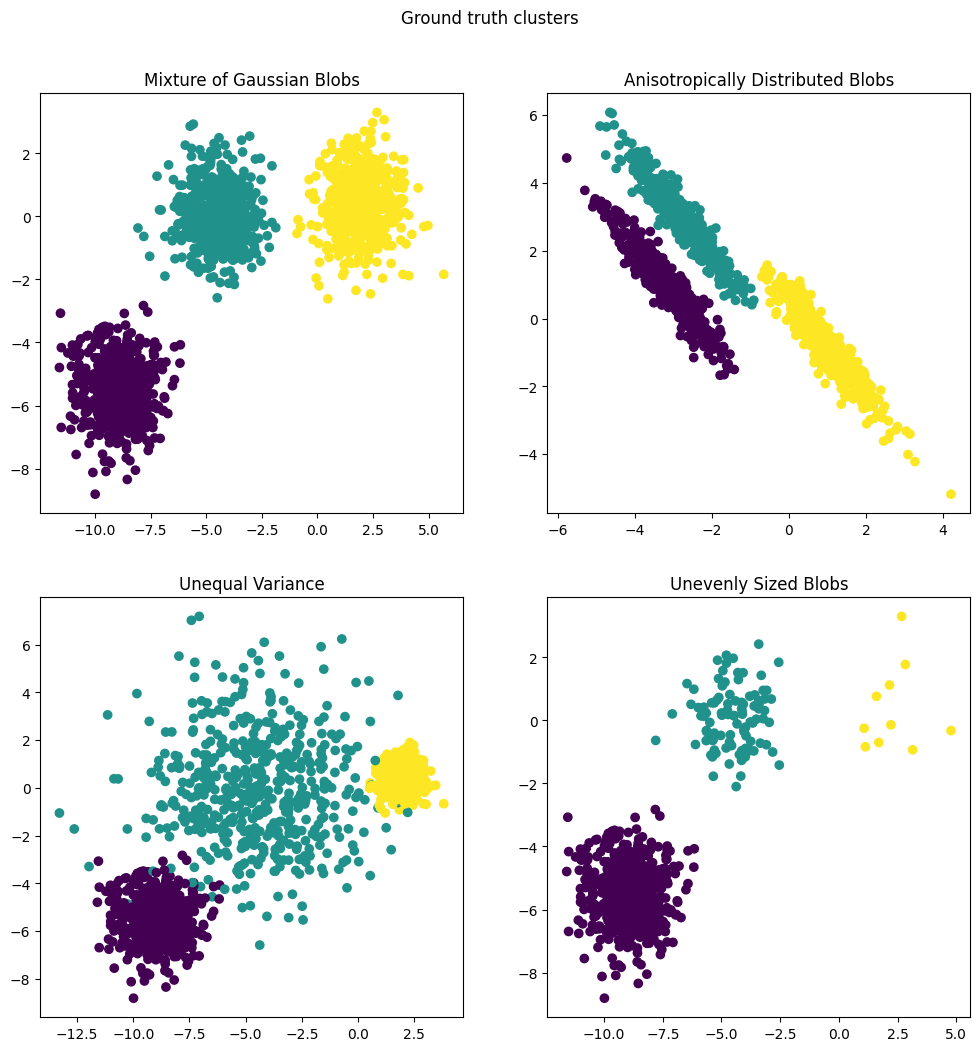

In [30]:
import numpy as np

from sklearn.datasets import make_blobs

n_samples = 1500
random_state = 170
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]

X, y = make_blobs(n_samples=n_samples, random_state=random_state)
X_aniso = np.dot(X, transformation) # Anisotropic blobs
X_varied, y_varied = make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
) # Unequal variance
X_filtered = np.vstack(
    (X[y == 0][:500], X[y == 1][:100], X[y == 2][:10])
) # Unevenly sized blobs
y_filtered = [0] * 500 + [1] * 100 + [2] * 10

import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

axs[0, 0].scatter(X[:, 0], X[:, 1], c=y)
axs[0, 0].set_title("Mixture of Gaussian Blobs")

axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=y_varied)
axs[1, 0].set_title("Unequal Variance")

axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_filtered)
axs[1, 1].set_title("Unevenly Sized Blobs")
plt.suptitle("Ground truth clusters").set_y(0.95)
plt.show()

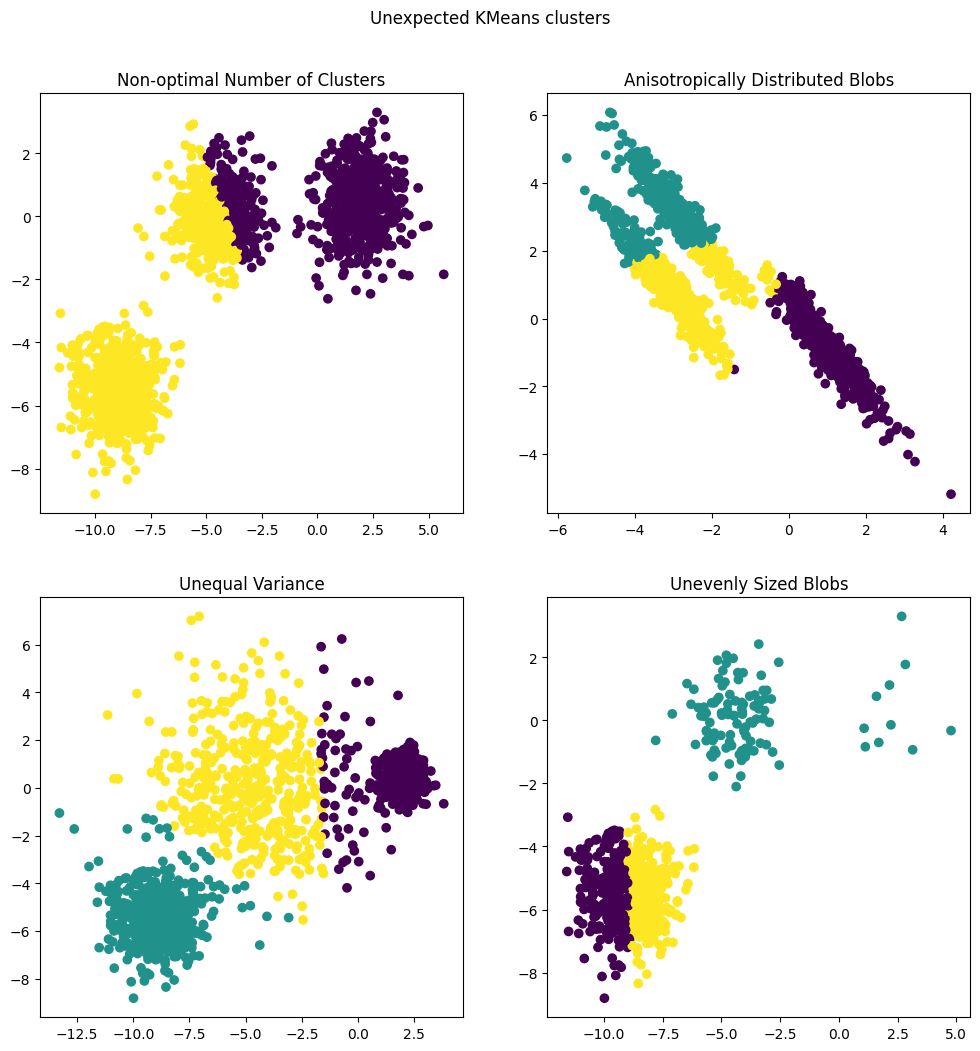

In [31]:
from sklearn.cluster import KMeans

common_params = {
    "n_init": "auto",
    "random_state": random_state,
}

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

y_pred = KMeans(n_clusters=2, **common_params).fit_predict(X)
axs[0, 0].scatter(X[:, 0], X[:, 1], c=y_pred)
axs[0, 0].set_title("Non-optimal Number of Clusters")

y_pred = KMeans(n_clusters=3, **common_params).fit_predict(X_aniso)
axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_pred)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

y_pred = KMeans(n_clusters=3, **common_params).fit_predict(X_varied)
axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=y_pred)
axs[1, 0].set_title("Unequal Variance")

y_pred = KMeans(n_clusters=3, **common_params).fit_predict(X_filtered)
axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("Unexpected KMeans clusters").set_y(0.95)
plt.show()

## 3.2 Local Outlier Factor

Local Outlier Factor (LOF) identifies observations whose local density is substantially lower than the density of their neighbors.

The following synthetic example creates a set of inliers and uniformly distributed outliers, fits LOF, and visualizes anomaly scores using marker size.

In [32]:
import numpy as np

np.random.seed(42)

X_inliers = 0.3 * np.random.randn(100, 2)
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X = np.r_[X_inliers, X_outliers]

n_outliers = len(X_outliers)
ground_truth = np.ones(len(X), dtype=int)
ground_truth[-n_outliers:] = -1

In [33]:
from sklearn.neighbors import LocalOutlierFactor
clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred = clf.fit_predict(X)
n_errors = (y_pred != ground_truth).sum()
X_scores = clf.negative_outlier_factor_

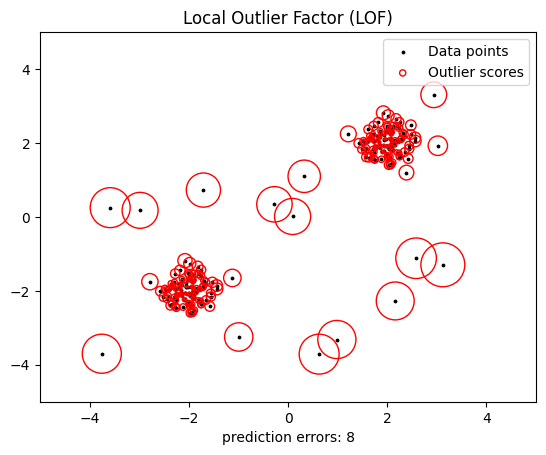

In [34]:
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerPathCollection


def update_legend_marker_size(handle, orig):
    "Customize size of the legend marker"
    handle.update_from(orig)
    handle.set_sizes([20])


plt.scatter(X[:, 0], X[:, 1], color="k", s=3.0, label="Data points")
# plot circles with radius proportional to the outlier scores
radius = (X_scores.max() - X_scores) / (X_scores.max() - X_scores.min())
scatter = plt.scatter(
    X[:, 0],
    X[:, 1],
    s=1000 * radius,
    edgecolors="r",
    facecolors="none",
    label="Outlier scores",
)
plt.axis("tight")
plt.xlim((-5, 5))
plt.ylim((-5, 5))
plt.xlabel("prediction errors: %d" % (n_errors))
plt.legend(
    handler_map={scatter: HandlerPathCollection(update_func=update_legend_marker_size)}
)
plt.title("Local Outlier Factor (LOF)")
plt.show()

# 4. Key Takeaways

This notebook provides a compact comparison of several foundational machine-learning approaches:

- **KNN** demonstrates instance-based learning for both classification and regression.
- **Logistic Regression** illustrates probabilistic classification and threshold-independent ROC evaluation.
- **SVM kernels** show how model assumptions change the geometry of a decision boundary.
- **OLS, Ridge, and Lasso** demonstrate the effect of regularization on linear regression.
- **Decision Trees and Gradient Boosting** introduce tree-based predictive modeling at different levels of complexity.
- **K-Means** illustrates both the usefulness and limitations of centroid-based clustering.
- **LOF** demonstrates density-based outlier detection.

The notebook is best viewed as a **technical fundamentals showcase**: a set of controlled examples that demonstrate how common algorithms are constructed, evaluated, and visualized using scikit-learn.